In [1]:
import pandas as pd
df = pd.read_csv('final_results_long_format.csv')

In [2]:
df.head()

,source,question,answer,writer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers


In [3]:
df['question_clean'] = (
    df['question']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['question_clean'] = df['question_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [4]:
df['answer_clean'] = (
    df['answer']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['answer_clean'] = df['answer_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [5]:
df['answer_clean'].head(20)

0     Imagine you have a toy train. Some toy trains ...
1     In conjunction with the software , the IR sens...
2     The authorities in the case would have gathere...
3     Emulators are programs that allow a computer t...
4     In the US , pretty much all blacks originally ...
5     Imagine you have a box with a toy inside. You ...
6     The car dealership doesn't care where you get ...
7     Judging market efficiency solely from raw pric...
8     Imagine you're eating a candy. Some candies ar...
9     Martial arts can be effective in a street figh...
10    To continue your scholarships , generally . Mo...
11    Easter is a holiday that celebrates the resurr...
12    Isopropyl alcohol is a type of alcohol that ca...
13    All parties in WWII engaged in extensive bombi...
14    Hiroshima and Nagasaki are both densely popula...
15    Chemotherapy is a poison designed to kill fast...
16    Imagine you're swinging a ball on a string aro...
17    In Japanese, it is common to add certain w

In [6]:
df['answer_length'] = df['answer'].apply(lambda x: len(x.split()))
df['question_length'] = df['question'].apply(lambda x: len(x.split()))

In [7]:
df.shape

(62845, 8)

In [8]:
# Select only answers with length between 150 and 350
#df_length_controlled = df[(df['answer_length'] >= 150) & (df['answer_length'] <= 350)].copy()

In [9]:
df.groupby('writer')['answer_length'].count()

writer
answer_gemini      20845
chatgpt_answers    21000
human_answers      21000
Name: answer_length, dtype: int64

In [10]:
df.shape

(62845, 8)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['answer'])
tfidf_scores = tfidf_matrix.mean(axis=1)

In [12]:
df.head()

,source,question,answer,writer,question_clean,answer_clean,answer_length,question_length
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,150,23
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens...",498,38
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...,129,44
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...,160,53
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ...",650,24


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

question_vecs = vectorizer.fit_transform(df['question'])
answer_vecs = vectorizer.transform(df['answer_clean'])

df['cosine_sim'] = [
    cosine_similarity(question_vecs[i], answer_vecs[i])[0][0]
    for i in range(len(df))
]

In [14]:
df.head()

,source,question,answer,writer,question_clean,answer_clean,answer_length,question_length,cosine_sim
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,150,23,0.217907
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens...",498,38,0.019536
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...,129,44,0.084541
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...,160,53,0.142301
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ...",650,24,0.126231


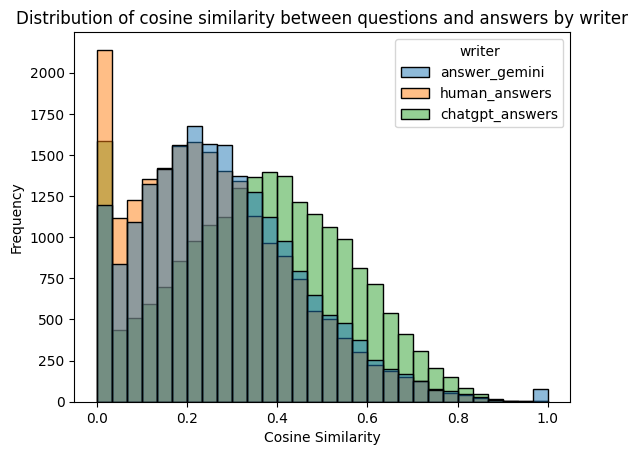

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(data = df, x = 'cosine_sim', hue = 'writer', hue_order=['answer_gemini', 'human_answers', 'chatgpt_answers'], bins=30)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by writer')
plt.show()

In [16]:
df = df[
    [
        'question_clean',
        'answer_clean',
        'writer',
        'answer_length',
        'cosine_sim',
        'source',
        'question',
        'answer'
    ]
]
df.head(1)

,question_clean,answer_clean,writer,answer_length,cosine_sim,source,question,answer
0,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,answer_gemini,150,0.217907,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...


In [17]:
df_human_answers = df[df['writer'] == 'human_answers']
df_gpt_answers = df[df['writer'] == 'chatgpt_answers']
df_gemini_answers = df[df['writer'] == 'answer_gemini']

In [18]:
from collections import Counter

char_counter_human = Counter()
char_counter_gpt = Counter()
char_counter_gemini = Counter()

for q in df_human_answers['answer_clean']:
    char_counter_human.update(q)

for q in df_gpt_answers['answer_clean']:
    char_counter_gpt.update(q)

for q in df_gemini_answers['answer_clean']:
    char_counter_gemini.update(q)

In [19]:
char_counter_gemini.most_common(20)

[(' ', 4230793),
 ('e', 2339740),
 ('t', 1734470),
 ('a', 1480509),
 ('o', 1461080),
 ('i', 1374301),
 ('s', 1292249),
 ('n', 1265729),
 ('r', 1125530),
 ('l', 874012),
 ('h', 835283),
 ('u', 611574),
 ('d', 598786),
 ('c', 561814),
 ('y', 505950),
 ('m', 492595),
 ('g', 490425),
 ('p', 406660),
 ('f', 369539),
 ('*', 327960)]